In [7]:
import json
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
import pandas as pd
from pathlib import Path


/var/folders/wp/zz11dqlj2xg4yt1xmynhrc8c0000gn/T/ipykernel_81628/1647366103.py:139: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


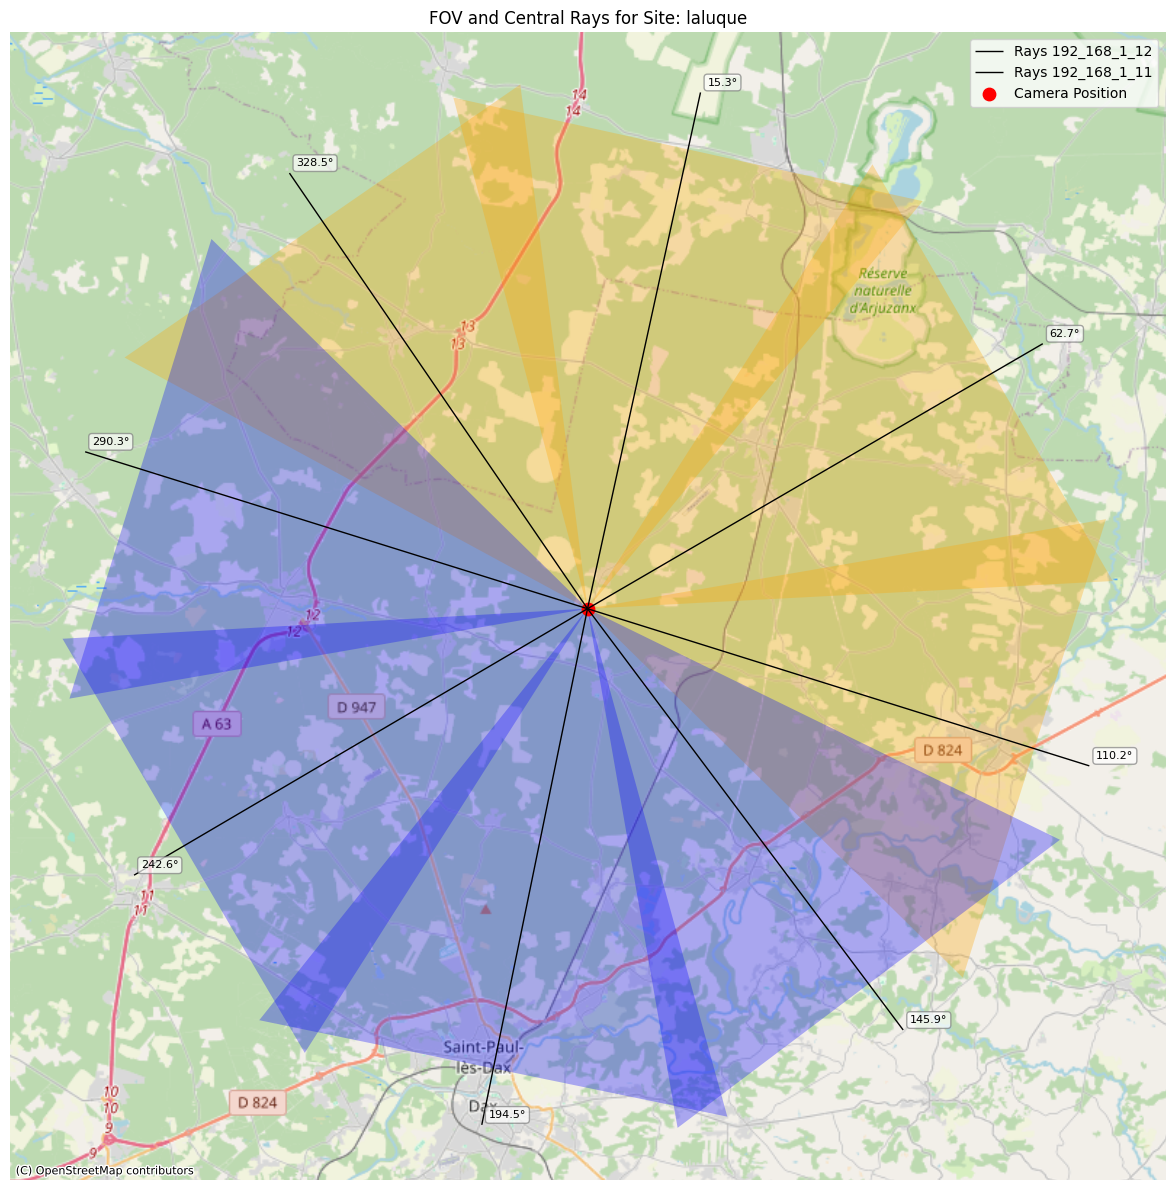

In [9]:
import json
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
import pandas as pd
from pathlib import Path

# ------------------- Configuration -------------------

# Define site name
site = 'laluque'

# Base path
base_path = Path(f'/Users/mateo/pyronear/vision/smoke-localization/site_data/{site}')

# Load camera position from config
with open(base_path / 'camera_config.json') as f:
    config = json.load(f)

lon, lat = config['lon'], config['lat']

# Convert camera coordinates to EPSG:2154
transformer = Transformer.from_crs("EPSG:4326", "EPSG:2154", always_xy=True)
cam_x, cam_y = transformer.transform(lon, lat)
cam_loc = (cam_x, cam_y, 0, "EPSG:2154")

# Find all azimuth JSON files
pose_files = list((base_path / 'captured_poses').glob('*_full_azimuth.json'))

# Pose filters per camera (set to None to display all)
pose_filters = {
    '192_168_1_11': [2, 5],
    '192_168_1_12': [2, 5],
    # Add other cameras here if needed
}

# ------------------- Helper Functions -------------------

def build_fov_geometries(cam_loc, azimuth_deg, fov_deg=54.2, view_distance=20000):
    cam_x, cam_y, _, _ = cam_loc
    cam_point = Point(cam_x, cam_y)
    half_fov = fov_deg / 2
    angles_deg = [azimuth_deg - half_fov, azimuth_deg + half_fov]
    angles_rad = np.radians(angles_deg)

    # Build FOV triangle
    cone_pts = [
        cam_point,
        Point(cam_x + view_distance * np.sin(angles_rad[0]), cam_y + view_distance * np.cos(angles_rad[0])),
        Point(cam_x + view_distance * np.sin(angles_rad[1]), cam_y + view_distance * np.cos(angles_rad[1]))
    ]
    gdf_fov = gpd.GeoSeries([
        g.convex_hull for g in [cone_pts[0].buffer(1).union(cone_pts[1]).union(cone_pts[2])]
    ], crs="EPSG:2154")

    # Build central ray
    azimuth_rad = np.radians(azimuth_deg)
    target_x = cam_x + view_distance * np.sin(azimuth_rad)
    target_y = cam_y + view_distance * np.cos(azimuth_rad)
    ray = LineString([(cam_x, cam_y), (target_x, target_y)])
    gdf_ray = gpd.GeoSeries([ray], crs="EPSG:2154")

    return gdf_fov, gdf_ray

# ------------------- Processing -------------------

all_fovs = []
all_rays = []
all_cam_names = []
all_ray_angles = []

for pose_file in pose_files:
    with open(pose_file) as f:
        az_dict = json.load(f)

    cam_name = pose_file.stem.split('_full_azimuth')[0]
    filter_range = pose_filters.get(cam_name, None)

    filtered_azimuths = []
    for filename, az in az_dict.items():
        try:
            pose_id = int(filename.split('_im_')[1].split('.jpg')[0])
            if filter_range is None or (filter_range[0] <= pose_id <= filter_range[1]):
                filtered_azimuths.append((az, pose_id))
        except (IndexError, ValueError):
            continue

    if not filtered_azimuths:
        continue

    # Build geometries
    fov_list = []
    ray_geoms = []
    ray_angles = []

    for az, _ in filtered_azimuths:
        fov, ray = build_fov_geometries(cam_loc, az)
        fov_list.append(fov)
        ray_geoms.append(ray[0])
        ray_angles.append(az)

    gdf_fov = gpd.GeoSeries(pd.concat(fov_list, ignore_index=True)).set_crs("EPSG:2154")
    gdf_ray = gpd.GeoSeries(ray_geoms, crs="EPSG:2154")

    all_fovs.append(gdf_fov)
    all_rays.append(gdf_ray)
    all_cam_names.append(cam_name)
    all_ray_angles.append(ray_angles)

# ------------------- Plotting -------------------

gdf_cam = gpd.GeoSeries([Point(cam_x, cam_y)], crs="EPSG:2154").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
colors = ['orange', 'blue', 'green', 'purple', 'cyan']

for i, (fov, ray, name, angles) in enumerate(zip(all_fovs, all_rays, all_cam_names, all_ray_angles)):
    fov_web = fov.to_crs(epsg=3857)
    ray_web = ray.to_crs(epsg=3857)
    color = colors[i % len(colors)]

    fov_web.plot(ax=ax, color=color, alpha=0.3, label=f"FOV {name}")
    ray_web.plot(ax=ax, color='black', linewidth=1, label=f"Rays {name}")

    for geom, az in zip(ray_web.geometry, angles):
        x_end, y_end = geom.coords[-1]
        ax.annotate(f"{az:.1f}°", (x_end, y_end), xytext=(5, 5), textcoords="offset points",
                    fontsize=8, color="black",
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round'))

gdf_cam.plot(ax=ax, color='red', markersize=80, label="Camera Position")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"FOV and Central Rays for Site: {site}")
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()
